In [1]:
import pickle
import numpy as np
import torch
from collections import Counter

# ============ inspect ============
def _shape_dtype(x):
    if x is None:
        return "MISSING", "MISSING", "None"
    t = type(x).__name__
    if torch.is_tensor(x):
        return tuple(x.shape), str(x.dtype), t
    if isinstance(x, np.ndarray):
        return x.shape, str(x.dtype), t
    if hasattr(x, "shape"):
        try:
            return tuple(x.shape), str(getattr(x, "dtype", "N/A")), t
        except Exception:
            pass
    return "N/A", "N/A", t

def inspect_pkl_items(
    file_path: str,
    emotions=None,
    max_print: int = None,
    start_index: int = 0,
    print_missing: bool = True,
    return_data: bool = True,
    show_stats: bool = False,
):
    with open(file_path, "rb") as f:
        data = pickle.load(f)

    keys_basic = [
        "Sr No.", "uni_id", "Speaker", "Utterance", "Emotion", "Sentiment",
        "Dialogue_ID", "Utterance_ID", "Season", "Episode",
        "StartTime", "EndTime",
        "raw_function", "function",
        "vision_image_path"
    ]

    keys_flags = [
        "text_modal", "audio_modal", "vision_modal",
        "semantic_modal", "caption_modal",
        "semantic_masked_modal", "oneliner_modal"
    ]

    keys_llm_text = ["semantic_explanation", "vision_caption"]
    keys_new_text = ["semantic_masked_text", "oneliner_text"]

    keys_features = [
        "text_feature",
        "audio_feature",
        "vision_feature",
        "semantic_feature",
        "caption_feature",
        "semantic_masked_roberta_feat",
        "oneliner_roberta_feat",
    ]

    printed = 0
    for i in range(start_index, len(data)):
        item = data[i]
        emo = item.get("Emotion", None)
        if emotions is not None and emo not in emotions:
            continue

        print(f"\n========== Item {i} ==========")

        print("[Basic]")
        for k in keys_basic:
            if k in item:
                v = item.get(k)
                if k == "Utterance" and isinstance(v, str) and len(v) > 160:
                    v = v[:160] + "..."
                print(f"  {k}: {v}")
            else:
                if print_missing:
                    print(f"  {k}: MISSING")

        print("[Modal Flags]")
        for k in keys_flags:
            print(f"  {k}: {item.get(k, 'MISSING')}")

        print("[LLM Text Fields]")
        for k in keys_llm_text:
            v = item.get(k, None)
            if v is None:
                if print_missing: print(f"  {k}: MISSING")
            else:
                if isinstance(v, str) and len(v) > 220:
                    v = v[:220] + "..."
                print(f"  {k}: {v}")

        print("[New Text Fields]")
        for k in keys_new_text:
            v = item.get(k, None)
            if v is None:
                if print_missing: print(f"  {k}: MISSING")
            else:
                if isinstance(v, str) and len(v) > 220:
                    v = v[:220] + "..."
                print(f"  {k}: {v}")

        print("[Features]")
        for k in keys_features:
            x = item.get(k, None)
            shape, dtype, t = _shape_dtype(x)
            print(f"  {k}: type={t}, shape={shape}, dtype={dtype}")

        extra_keys = []
        for kk in item.keys():
            if kk in keys_features: 
                continue
            if kk.endswith("_feature") or kk.endswith("_roberta_feat"):
                extra_keys.append(kk)
        if extra_keys:
            print("[Extra Feature Keys]")
            for kk in sorted(extra_keys):
                x = item.get(kk, None)
                shape, dtype, t = _shape_dtype(x)
                print(f"  {kk}: type={t}, shape={shape}, dtype={dtype}")

        printed += 1
        if max_print is not None and printed >= max_print:
            break

    print(f"\n[Done] Loaded: {len(data)} items | Printed: {printed} items from {file_path}")
    return data if return_data else None


# ========================
def build_label_map(train_data, label_key_candidates=("Emotion", "emotion", "label")):
    used_key = None
    for k in label_key_candidates:
        if all((k in it) for it in train_data):
            used_key = k
            labels = [str(it[k]).strip() for it in train_data]
            break
    if used_key is None:
        raise KeyError(f"Cannot find label key. Tried: {label_key_candidates}")

    uniq = sorted(set(labels))
    label2id = {lab: i for i, lab in enumerate(uniq)}
    return used_key, label2id

def encode_labels(data, label_key, label2id, unknown_policy="error"):
    y = []
    unk = 0
    for it in data:
        lab = str(it.get(label_key, "")).strip()
        if lab in label2id:
            y.append(label2id[lab])
        else:
            unk += 1
            if unknown_policy == "error":
                raise ValueError(f"Unknown label '{lab}' not in label2id.")
            y.append(-1)
    return np.array(y, dtype=np.int64), unk

def build_function_map(train_data, func_key="function"):
    funcs = []
    for it in train_data:
        v = it.get(func_key, None)
        if v is None:
            funcs.append("MISSING")
        else:
            s = str(v).strip()
            funcs.append(s if s else "EMPTY")
    uniq = sorted(set(funcs))
    if "MISSING" not in uniq:
        uniq = ["MISSING"] + uniq
    return {f: i for i, f in enumerate(uniq)}

def encode_functions(data, func2id, func_key="function"):
    ids = []
    miss = 0
    for it in data:
        v = it.get(func_key, None)
        if v is None:
            miss += 1
            ids.append(func2id.get("MISSING", -1))
        else:
            s = str(v).strip()
            ids.append(func2id.get(s if s else "EMPTY", func2id.get("MISSING", -1)))
    return np.array(ids, dtype=np.int64), miss

def get_first_existing(item, keys):
    for k in keys:
        if k in item and item[k] is not None:
            return item[k], k
    return None, None


# ============input============
def extract_split_v3_six_inputs(
    data, *, label_key, label2id, func2id,
    unknown_label_policy="error",
    key_text_raw=("text_feature",),
    key_text_sem=("semantic_masked_roberta_feat", "semantic_feature"),
    key_audio=("audio_feature",),
    key_audio_llm=("oneliner_roberta_feat",),
    key_vis_raw=("vision_feature", "vision_feature_resnet", "vision_feat"),
    key_vis_cap=("caption_feature",),
):
    y, unk_y = encode_labels(data, label_key, label2id, unknown_policy=unknown_label_policy)
    func_id, miss_func = encode_functions(data, func2id, func_key="function")

    X_text_raw, X_text_sem = [], []
    X_audio, X_audio_llm = [], []
    X_vis_raw, X_vis_cap = [], []

    missing = Counter()
    used_keys = Counter()

    for it in data:
        x, used = get_first_existing(it, key_text_raw)
        if x is None: missing["text_raw"] += 1
        else: used_keys[f"text_raw::{used}"] += 1
        X_text_raw.append(x)

        x, used = get_first_existing(it, key_text_sem)
        if x is None: missing["text_sem"] += 1
        else: used_keys[f"text_sem::{used}"] += 1
        X_text_sem.append(x)

        x, used = get_first_existing(it, key_audio)
        if x is None: missing["audio"] += 1
        else: used_keys[f"audio::{used}"] += 1
        X_audio.append(x)

        x, used = get_first_existing(it, key_audio_llm)
        if x is None: missing["audio_llm"] += 1
        else: used_keys[f"audio_llm::{used}"] += 1
        X_audio_llm.append(x)

        x, used = get_first_existing(it, key_vis_raw)
        if x is None: missing["vision_raw"] += 1
        else: used_keys[f"vision_raw::{used}"] += 1
        X_vis_raw.append(x)

        x, used = get_first_existing(it, key_vis_cap)
        if x is None: missing["vision_cap"] += 1
        else: used_keys[f"vision_cap::{used}"] += 1
        X_vis_cap.append(x)

    return {
        "y": y,
        "func_id": func_id,
        "X_text_raw": X_text_raw,
        "X_text_sem": X_text_sem,
        "X_audio": X_audio,
        "X_audio_llm": X_audio_llm,
        "X_vis_raw": X_vis_raw,
        "X_vis_cap": X_vis_cap,
        "missing": dict(missing),
        "used_keys": dict(used_keys),
        "unknown_labels": int(unk_y),
        "missing_function": int(miss_func),
    }


# ========================
train_path = "/root/autodl-tmp/meld_Train_with_LLM_plus_masked_oneliner.pkl"
dev_path   = "/root/autodl-tmp/meld_dev_with_LLM_plus_masked_oneliner.pkl"
test_path  = "/root/autodl-tmp/meld_Test_with_LLM_plus_masked_oneliner.pkl"

train_data = inspect_pkl_items(train_path, emotions=None, max_print=2, show_stats=False)
valid_data = inspect_pkl_items(dev_path,   emotions=None, max_print=2, show_stats=False)
test_data  = inspect_pkl_items(test_path,  emotions=None, max_print=2, show_stats=False)

label_key, label2id = build_label_map(train_data, ("Emotion","label","emotion"))
func2id = build_function_map(train_data, func_key="function")

train_pack = extract_split_v3_six_inputs(train_data, label_key=label_key, label2id=label2id, func2id=func2id)
valid_pack = extract_split_v3_six_inputs(valid_data, label_key=label_key, label2id=label2id, func2id=func2id)
test_pack  = extract_split_v3_six_inputs(test_data,  label_key=label_key, label2id=label2id, func2id=func2id)

print("\nLabel key:", label_key, " | #classes:", len(label2id), " | #func:", len(func2id))
print("Missing(train):", train_pack["missing"])
print("Used keys(train):", train_pack["used_keys"])



========== Item 0 ==========
[Basic]
  Sr No.: 1
  uni_id: dia0_utt0
  Speaker: Chandler
  Utterance: also I was the point person on my companys transition from the KL-5 to GR-6 system.
  Emotion: neutral
  Sentiment: neutral
  Dialogue_ID: 0
  Utterance_ID: 0
  Season: 8
  Episode: 21
  StartTime: 00:16:16,059
  EndTime: 00:16:21,731
  raw_function: explanation
  function: explanation
  vision_image_path: /root/autodl-tmp/MELD.Raw/train_splits/dia0_utt0/0002.png
[Modal Flags]
  text_modal: MISSING
  audio_modal: 1
  vision_modal: 1
  semantic_modal: 1
  caption_modal: 1
  semantic_masked_modal: 1
  oneliner_modal: 1
[LLM Text Fields]
  semantic_explanation: This utterance informs the other speaker about Chandler's role in a significant project, which may establish credibility and provide context for the conversation.
  vision_caption: Two men are seated in an office setting; one is in a chair behind a desk facing the other, who is sitting across from him with papers and a telephone 

In [2]:
import numpy as np
from collections import Counter

# ---------- 1) Encoding：Emotion -> id ----------
def build_label_map(train_data, label_key_candidates=("Emotion", "emotion", "label")):
    labels = []
    used_key = None
    for k in label_key_candidates:
        if all((k in it) for it in train_data):
            used_key = k
            labels = [it[k] for it in train_data]
            break
    if used_key is None:
        raise KeyError(f"Cannot find label key in train_data. Tried: {label_key_candidates}")

    labels = [str(x).strip() for x in labels]
    uniq = sorted(set(labels))
    label2id = {lab: i for i, lab in enumerate(uniq)}
    return used_key, label2id

def encode_labels(data, label_key, label2id, unknown_policy="error"):
    y = []
    unk = 0
    for it in data:
        lab = str(it.get(label_key, "")).strip()
        if lab in label2id:
            y.append(label2id[lab])
        else:
            unk += 1
            if unknown_policy == "error":
                raise ValueError(f"Unknown label '{lab}' not in label2id.")
            elif unknown_policy == "skip":
                y.append(None)
            else:
                y.append(-1)
    return np.array(y, dtype=object), unk


# ---------- 2) function encoding：function -> id ----------
def build_function_map(train_data, func_key="function", add_missing_token=True):
    funcs = []
    for it in train_data:
        v = it.get(func_key, None)
        if v is None:
            funcs.append("MISSING")
        else:
            s = str(v).strip()
            funcs.append(s if s else "EMPTY")

    uniq = sorted(set(funcs))
    if add_missing_token and "MISSING" not in uniq:
        uniq = ["MISSING"] + uniq

    return {f: i for i, f in enumerate(uniq)}

def encode_functions(data, func2id, func_key="function"):
    ids = []
    miss = 0
    for it in data:
        v = it.get(func_key, None)
        if v is None:
            miss += 1
            ids.append(func2id.get("MISSING", -1))
        else:
            s = str(v).strip()
            ids.append(func2id.get(s if s else "EMPTY", func2id.get("MISSING", -1)))
    return np.array(ids, dtype=np.int64), miss


# ---------- 3)----------
def get_first_existing(item, keys):
    for k in keys:
        if k in item and item[k] is not None:
            return item[k], k
    return None, None

def extract_split_v3_six_inputs(
    data, *, label_key, label2id, func2id,
    key_text_raw=("text_feature",),
    key_text_sem=("semantic_masked_roberta_feat", "semantic_feature"),  # masked
    key_audio=("audio_feature",),                                      # hubert
    key_audio_llm=("oneliner_roberta_feat",),                          # Audio with LLM
    key_vis_raw=("vision_feature", "vision_feature_resnet", "vision_feature_dense", "vision_feat"),
    key_vis_cap=("caption_feature",),
    unknown_label_policy="error",
):
    y, unk_y = encode_labels(data, label_key, label2id, unknown_policy=unknown_label_policy)
    func_id, miss_func = encode_functions(data, func2id, func_key="function")

    X_text_raw, X_text_sem = [], []
    X_audio, X_audio_llm = [], []
    X_vis_raw, X_vis_cap = [], []

    missing = Counter()
    used_keys = Counter()

    for it in data:
        x, used = get_first_existing(it, key_text_raw)
        if x is None: missing["text_raw"] += 1
        else: used_keys[f"text_raw::{used}"] += 1
        X_text_raw.append(x)

        x, used = get_first_existing(it, key_text_sem)
        if x is None: missing["text_sem"] += 1
        else: used_keys[f"text_sem::{used}"] += 1
        X_text_sem.append(x)

        x, used = get_first_existing(it, key_audio)
        if x is None: missing["audio"] += 1
        else: used_keys[f"audio::{used}"] += 1
        X_audio.append(x)

        x, used = get_first_existing(it, key_audio_llm)
        if x is None: missing["audio_llm"] += 1
        else: used_keys[f"audio_llm::{used}"] += 1
        X_audio_llm.append(x)

        x, used = get_first_existing(it, key_vis_raw)
        if x is None: missing["vision_raw"] += 1
        else: used_keys[f"vision_raw::{used}"] += 1
        X_vis_raw.append(x)

        x, used = get_first_existing(it, key_vis_cap)
        if x is None: missing["vision_cap"] += 1
        else: used_keys[f"vision_cap::{used}"] += 1
        X_vis_cap.append(x)

    return {
        "y": y,
        "func_id": func_id,
        "X_text_raw": X_text_raw,
        "X_text_sem": X_text_sem,
        "X_audio": X_audio,
        "X_audio_llm": X_audio_llm,
        "X_vis_raw": X_vis_raw,
        "X_vis_cap": X_vis_cap,
        "missing": dict(missing),
        "used_keys": dict(used_keys),
        "unknown_labels": int(unk_y),
        "missing_function": int(miss_func),
    }


# ---------- 4)  train/valid/test ----------
# train_data / valid_data / test_data
label_key, label2id = build_label_map(train_data, ("Emotion", "label", "emotion"))
func2id = build_function_map(train_data, func_key="function")

train_pack = extract_split_v3_six_inputs(train_data, label_key=label_key, label2id=label2id, func2id=func2id)
valid_pack = extract_split_v3_six_inputs(valid_data, label_key=label_key, label2id=label2id, func2id=func2id)
test_pack  = extract_split_v3_six_inputs(test_data,  label_key=label_key, label2id=label2id, func2id=func2id)

print("Label key used:", label_key)
print("Num emotion classes:", len(label2id))
print("Num function classes:", len(func2id))

print("\nMissing stats (train):", train_pack["missing"])
print("Missing stats (valid):", valid_pack["missing"])
print("Missing stats (test):",  test_pack["missing"])

print("\nUsed keys (train):", train_pack["used_keys"])

Label key used: Emotion
Num emotion classes: 7
Num function classes: 12

Missing stats (train): {'audio_llm': 6, 'audio': 1, 'vision_raw': 1}
Missing stats (valid): {'audio_llm': 3, 'audio': 1, 'vision_raw': 1}
Missing stats (test): {'audio': 2, 'vision_raw': 2}

Used keys (train): {'text_raw::text_feature': 9989, 'text_sem::semantic_masked_roberta_feat': 9989, 'audio::audio_feature': 9988, 'audio_llm::oneliner_roberta_feat': 9983, 'vision_raw::vision_feature': 9988, 'vision_cap::caption_feature': 9989}


In [3]:
label_key, label2id = build_label_map(train_data, ("Emotion", "label", "emotion"))
func2id = build_function_map(train_data, func_key="function")

print("Label key used:", label_key)
print("Num emotion classes:", len(label2id))
#print("Num function classes:", len(func2id))

Label key used: Emotion
Num emotion classes: 7


In [4]:
print("\n===== label2id =====")
for k, v in label2id.items():
    print(f"{k} -> {v}")

id2label = {v: k for k, v in label2id.items()}

print("\n===== id2label =====")
for i in range(len(id2label)):
    print(f"class_{i} = {id2label[i]}")


===== label2id =====
anger -> 0
disgust -> 1
fear -> 2
joy -> 3
neutral -> 4
sadness -> 5
surprise -> 6

===== id2label =====
class_0 = anger
class_1 = disgust
class_2 = fear
class_3 = joy
class_4 = neutral
class_5 = sadness
class_6 = surprise


In [5]:
import torch
import numpy as np

def prepare_feature_list(feature_list, modality=None, dtype=torch.float32):
    """
    List[ np.ndarray | torch.Tensor | None ] -> List[ torch.Tensor | None ]
    """
    out = []
    for feat in feature_list:
        if feat is None:
            out.append(None)
            continue

        # to tensor
        if torch.is_tensor(feat):
            x = feat.detach().to(dtype)
        else:
            x = torch.tensor(feat, dtype=dtype)

        # (1,L,D) -> (L,D)
        if x.dim() == 3 and x.size(0) == 1:
            x = x.squeeze(0)

        # For vision_raw: if it becomes of shape (D,), pad it back to (1, D).
        if modality == "vision_raw" and x.dim() == 1:
            x = x.unsqueeze(0)

        # (1,D)For audio_llm: if it becomes of shape (D,), pad it back to (1, D).
        if modality == "audio_llm" and x.dim() == 1:
            x = x.unsqueeze(0)

        out.append(x)
    return out


packs = {"train": train_pack, "valid": valid_pack, "test": test_pack}

features = {
    "text_raw":   {s: packs[s]["X_text_raw"]   for s in packs},
    "text_sem":   {s: packs[s]["X_text_sem"]   for s in packs},
    "audio":      {s: packs[s]["X_audio"]      for s in packs},
    "audio_llm":  {s: packs[s]["X_audio_llm"]  for s in packs},
    "vision_raw": {s: packs[s]["X_vis_raw"]    for s in packs},
    "vision_cap": {s: packs[s]["X_vis_cap"]    for s in packs},
}

processed_features = {}
for modality, splits in features.items():
    processed_features[modality] = {}
    for split, feat_list in splits.items():
        processed_features[modality][split] = prepare_feature_list(
            feat_list,
            modality=modality,
        )

        # print for test
        shown = 0
        for i, x in enumerate(processed_features[modality][split]):
            if x is None:
                continue
            print(f"[{modality} | {split}] sample {i} shape: {tuple(x.shape)}")
            shown += 1
            if shown >= 3:
                break

[text_raw | train] sample 0 shape: (26, 768)
[text_raw | train] sample 1 shape: (12, 768)
[text_raw | train] sample 2 shape: (10, 768)
[text_raw | valid] sample 0 shape: (21, 768)
[text_raw | valid] sample 1 shape: (4, 768)
[text_raw | valid] sample 2 shape: (24, 768)
[text_raw | test] sample 0 shape: (18, 768)
[text_raw | test] sample 1 shape: (39, 768)
[text_raw | test] sample 2 shape: (7, 768)
[text_sem | train] sample 0 shape: (29, 768)
[text_sem | train] sample 1 shape: (32, 768)
[text_sem | train] sample 2 shape: (24, 768)
[text_sem | valid] sample 0 shape: (26, 768)
[text_sem | valid] sample 1 shape: (26, 768)
[text_sem | valid] sample 2 shape: (36, 768)
[text_sem | test] sample 0 shape: (32, 768)
[text_sem | test] sample 1 shape: (23, 768)
[text_sem | test] sample 2 shape: (33, 768)
[audio | train] sample 0 shape: (284, 1024)
[audio | train] sample 1 shape: (74, 1024)
[audio | train] sample 2 shape: (147, 1024)
[audio | valid] sample 0 shape: (140, 1024)
[audio | valid] sample 

In [6]:
def rebuild_pack(old_pack, split, processed_features):
    new_pack = dict(old_pack)

    new_pack["X_text_raw"]  = processed_features["text_raw"][split]
    new_pack["X_text_sem"]  = processed_features["text_sem"][split]
    new_pack["X_audio"]     = processed_features["audio"][split]
    new_pack["X_audio_llm"] = processed_features["audio_llm"][split]
    new_pack["X_vis_raw"]   = processed_features["vision_raw"][split]
    new_pack["X_vis_cap"]   = processed_features["vision_cap"][split]

    return new_pack


train_pack2 = rebuild_pack(train_pack, "train", processed_features)
valid_pack2 = rebuild_pack(valid_pack, "valid", processed_features)
test_pack2  = rebuild_pack(test_pack,  "test",  processed_features)

In [7]:
print(train_pack2.keys())

dict_keys(['y', 'func_id', 'X_text_raw', 'X_text_sem', 'X_audio', 'X_audio_llm', 'X_vis_raw', 'X_vis_cap', 'missing', 'used_keys', 'unknown_labels', 'missing_function'])


In [8]:
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import torch

# =========================
# 1) ContextWindowDataset 
# =========================
class ContextWindowDataset(Dataset):
    """
    Returns a context window (C utterances):
  - 6 input streams: each is a list of length C, with elements as Tensor(L, D) or None
    text_raw / text_sem / audio_raw / audio_llm / vision_raw / vision_cap
  - ctx_mask: [C]  True = valid utterance, False = padding
  - center_pos: [1]  position of the center utterance in the window (fixed as r = C//2)
  - y / func_id: labels for the center utterance
  - modal_mask: [C, 4]  indicates for each utterance whether text/audio/audio_llm/vision exists
"""
    def __init__(self, pack, meta_data, C=7, use_or_for_text_exist=True):
        super().__init__()
        assert C % 2 == 1, " It is more convenient to use an odd window size 𝐶(e.g., 7, 9, 11)."
        self.C = C
        self.r = C // 2
        self.use_or_for_text_exist = use_or_for_text_exist

        # labels & ids
        self.y = pack["y"]
        self.func_id = pack.get("func_id", None)

        # features (List[Tensor | None])
        self.text_raw  = pack["X_text_raw"]
        self.text_sem  = pack["X_text_sem"]
        self.audio_raw = pack["X_audio"]
        self.audio_llm = pack["X_audio_llm"]
        self.vis_raw   = pack["X_vis_raw"]
        self.vis_cap   = pack["X_vis_cap"]

        # meta
        self.meta = meta_data

        # dialogue -> indices (sorted by Utterance_ID)
        dialogs = defaultdict(list)
        for idx, it in enumerate(self.meta):
            did = it.get("Dialogue_ID", None)
            uid = it.get("Utterance_ID", None)
            dialogs[did].append((uid, idx))

        self.dialogs = {}
        self.pos_in_dialog = {}
        for did, lst in dialogs.items():
            lst_sorted = sorted(lst, key=lambda x: x[0])
            idxs = [idx for _, idx in lst_sorted]
            self.dialogs[did] = idxs
            for p, idx in enumerate(idxs):
                self.pos_in_dialog[idx] = p

        self.did_of = [it.get("Dialogue_ID", None) for it in self.meta]

    def __len__(self):
        return len(self.y)

    def _get_one(self, idx):
        tr = self.text_raw[idx]
        ts = self.text_sem[idx]
        ar = self.audio_raw[idx]
        al = self.audio_llm[idx]
        vr = self.vis_raw[idx]
        vc = self.vis_cap[idx]

        if self.use_or_for_text_exist:
            m_t = 0.0 if (tr is None and ts is None) else 1.0
        else:
            m_t = 0.0 if tr is None else 1.0

        m_ar = 0.0 if ar is None else 1.0
        m_al = 0.0 if al is None else 1.0
        m_v  = 0.0 if vr is None else 1.0

        mm = torch.tensor([m_t, m_ar, m_al, m_v], dtype=torch.float32)
        return tr, ts, ar, al, vr, vc, mm

    def __getitem__(self, center_idx):
        did = self.did_of[center_idx]
        idxs = self.dialogs[did]
        p = self.pos_in_dialog[center_idx]

        # window indices
        win_indices = []
        ctx_mask = []
        for offset in range(-self.r, self.r + 1):
            q = p + offset
            if 0 <= q < len(idxs):
                win_indices.append(idxs[q])
                ctx_mask.append(True)
            else:
                win_indices.append(None)
                ctx_mask.append(False)

        text_raw_list, text_sem_list = [], []
        audio_raw_list, audio_llm_list = [], []
        vis_raw_list, vis_cap_list = [], []
        modal_mask_list = []

        for wi in win_indices:
            if wi is None:
                text_raw_list.append(None)
                text_sem_list.append(None)
                audio_raw_list.append(None)
                audio_llm_list.append(None)
                vis_raw_list.append(None)
                vis_cap_list.append(None)
                modal_mask_list.append(torch.tensor([0.0, 0.0, 0.0, 0.0], dtype=torch.float32))
            else:
                tr, ts, ar, al, vr, vc, mm = self._get_one(wi)
                text_raw_list.append(tr)
                text_sem_list.append(ts)
                audio_raw_list.append(ar)
                audio_llm_list.append(al)
                vis_raw_list.append(vr)
                vis_cap_list.append(vc)
                modal_mask_list.append(mm)

        item = {
            "text_raw_list": text_raw_list,
            "text_sem_list": text_sem_list,
            "audio_raw_list": audio_raw_list,
            "audio_llm_list": audio_llm_list,
            "vision_raw_list": vis_raw_list,
            "vision_cap_list": vis_cap_list,
            "ctx_mask": torch.tensor(ctx_mask, dtype=torch.bool),   # [C]
            "center_pos": torch.tensor(self.r, dtype=torch.long),   # fix
            "modal_mask": torch.stack(modal_mask_list, dim=0),      # [C,4]
            "y": torch.tensor(int(self.y[center_idx]), dtype=torch.long),
        }
        if self.func_id is not None:
            item["func_id"] = torch.tensor(int(self.func_id[center_idx]), dtype=torch.long)
        return item


# =========================
# 2) pad_or_zeros
# =========================
def pad_or_zeros(seq_list, feat_dim: int, dtype=torch.float32):
    B = len(seq_list)
    lengths = [0 if x is None else x.size(0) for x in seq_list]
    Lmax = max(lengths) if lengths else 0

    if Lmax == 0:
        padded = torch.zeros(B, 1, feat_dim, dtype=dtype)
        lengths = torch.zeros(B, dtype=torch.long)
        pad_mask = torch.ones(B, 1, dtype=torch.bool)
        return padded, lengths, pad_mask

    padded_out, padmask_out = [], []
    for x, L in zip(seq_list, lengths):
        if x is None:
            padded_out.append(torch.zeros(Lmax, feat_dim, dtype=dtype))
            padmask_out.append(torch.ones(Lmax, dtype=torch.bool))
        else:
            x = x.to(dtype)
            if L < Lmax:
                pad_len = Lmax - L
                pad = torch.zeros(pad_len, feat_dim, dtype=dtype, device=x.device)
                padded_out.append(torch.cat([x, pad], dim=0))
                pm = torch.cat([
                    torch.zeros(L, dtype=torch.bool, device=x.device),
                    torch.ones(pad_len, dtype=torch.bool, device=x.device)
                ], dim=0)
                padmask_out.append(pm)
            else:
                padded_out.append(x)
                padmask_out.append(torch.zeros(Lmax, dtype=torch.bool, device=x.device))

    padded = torch.stack(padded_out, dim=0)
    lengths = torch.tensor(lengths, dtype=torch.long, device=padded.device)
    pad_mask = torch.stack(padmask_out, dim=0).to(padded.device)
    return padded, lengths, pad_mask


# =========================
# 3) collate_context_multi
# =========================
def collate_context_multi(batch, C=7):
    B = len(batch)
    out = {}
    out["y"] = torch.stack([b["y"] for b in batch], dim=0)                 # [B]
    out["ctx_mask"] = torch.stack([b["ctx_mask"] for b in batch], dim=0)   # [B,C]
    out["center_idx"] = torch.stack([b["center_pos"] for b in batch], 0)   # [B]
    out["modal_mask"] = torch.stack([b["modal_mask"] for b in batch], 0)   # [B,C,4]

    if "func_id" in batch[0]:
        out["func_id"] = torch.stack([b["func_id"] for b in batch], dim=0) # [B]

    def pad_context(list_name, feat_dim, out_x_key, out_mask_key):
        seq2d = [b[list_name] for b in batch]  # B x C

        padded_C = []
        validmask_C = []
        L_list = []

        for c in range(C):
            seq_list_c = [seq2d[bidx][c] for bidx in range(B)]
            padded, lengths, pad_mask = pad_or_zeros(seq_list_c, feat_dim=feat_dim)
            valid_mask = ~pad_mask
            padded_C.append(padded)
            validmask_C.append(valid_mask)
            L_list.append(padded.size(1))

        L_global = max(L_list) if L_list else 1

        def pad_to_L(x, m, L):
            Bx, Lx, D = x.shape
            if Lx == L:
                return x, m
            pad_len = L - Lx
            x_pad = torch.zeros(Bx, pad_len, D, dtype=x.dtype, device=x.device)
            m_pad = torch.zeros(Bx, pad_len, dtype=m.dtype, device=m.device)
            return torch.cat([x, x_pad], dim=1), torch.cat([m, m_pad], dim=1)

        padded_C2, valid_C2 = [], []
        for x, m in zip(padded_C, validmask_C):
            x2, m2 = pad_to_L(x, m, L_global)
            padded_C2.append(x2)
            valid_C2.append(m2)

        out[out_x_key] = torch.stack(padded_C2, dim=1)   # [B,C,L,D]
        out[out_mask_key] = torch.stack(valid_C2, dim=1) # [B,C,L]

    # 6 路
    pad_context("text_raw_list",    768,  "text_x",       "text_mask")
    pad_context("text_sem_list",    768,  "sem_x",        "sem_mask")
    pad_context("audio_raw_list",   1024, "audio_x",      "audio_mask")
    pad_context("audio_llm_list",   768,  "audio_llm_x",  "audio_llm_mask")  # ✅
    pad_context("vision_raw_list",  2048, "vision_x",     "vision_mask")
    pad_context("vision_cap_list",  768,  "cap_x",        "cap_mask")

    return out


# =========================
# 4) case
# =========================
C = 5 # For context
train_dataset = ContextWindowDataset(train_pack2, train_data, C=C, use_or_for_text_exist=True)
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    collate_fn=lambda b: collate_context_multi(b, C=C)
)

valid_dataset = ContextWindowDataset(valid_pack2, valid_data, C=C, use_or_for_text_exist=True)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    collate_fn=lambda b: collate_context_multi(b, C=C)
)

test_dataset = ContextWindowDataset(test_pack2, test_data, C=C, use_or_for_text_exist=True)
test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    collate_fn=lambda b: collate_context_multi(b, C=C)
)

batch = next(iter(train_loader))
print("text_x:", batch["text_x"].shape, "text_mask:", batch["text_mask"].shape)
print("sem_x:", batch["sem_x"].shape, "sem_mask:", batch["sem_mask"].shape)
print("audio_x:", batch["audio_x"].shape, "audio_mask:", batch["audio_mask"].shape)
print("audio_llm_x:", batch["audio_llm_x"].shape, "audio_llm_mask:", batch["audio_llm_mask"].shape)
print("vision_x:", batch["vision_x"].shape, "vision_mask:", batch["vision_mask"].shape)
print("cap_x:", batch["cap_x"].shape, "cap_mask:", batch["cap_mask"].shape)
print("ctx_mask:", batch["ctx_mask"].shape, "center_idx:", batch["center_idx"].shape)
print("modal_mask:", batch["modal_mask"].shape, "y:", batch["y"].shape)
if "func_id" in batch:
    print("func_id:", batch["func_id"].shape)

text_x: torch.Size([8, 5, 34, 768]) text_mask: torch.Size([8, 5, 34])
sem_x: torch.Size([8, 5, 50, 768]) sem_mask: torch.Size([8, 5, 50])
audio_x: torch.Size([8, 5, 493, 1024]) audio_mask: torch.Size([8, 5, 493])
audio_llm_x: torch.Size([8, 5, 19, 768]) audio_llm_mask: torch.Size([8, 5, 19])
vision_x: torch.Size([8, 5, 9, 2048]) vision_mask: torch.Size([8, 5, 9])
cap_x: torch.Size([8, 5, 49, 768]) cap_mask: torch.Size([8, 5, 49])
ctx_mask: torch.Size([8, 5]) center_idx: torch.Size([8])
modal_mask: torch.Size([8, 5, 4]) y: torch.Size([8])
func_id: torch.Size([8])


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast  # new AMP API


# =========================
# 1) AMP-safe Attention Pool
# =========================
class SafeAttnPool(nn.Module):
    """
    True AMP-safe attention pooling:
    - explicitly disable autocast inside module, force fp32 compute
    - cast output back to input dtype to remain AMP friendly
    mask: True=valid
    """
    def __init__(self, d_model=768, dropout=0.1):
        super().__init__()
        self.scorer = nn.Linear(d_model, 1)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        # x: [N,L,D], mask: [N,L] True=valid
        N, L, D = x.shape
        x_dtype = x.dtype

        with autocast("cuda", enabled=False):
            x32 = x.float()
            s = self.scorer(self.drop(x32)).squeeze(-1)  # [N,L] fp32

            valid_row = mask.any(dim=1)
            out32 = x32.new_zeros(N, D)  # [N,D] fp32

            if valid_row.any():
                xv = x32[valid_row]
                mv = mask[valid_row]
                sv = s[valid_row].masked_fill(~mv, float("-inf"))
                a = torch.softmax(sv, dim=-1)
                out_v = torch.bmm(a.unsqueeze(1), xv).squeeze(1)  # [Nv,D]
                out32[valid_row] = out_v.to(out32.dtype)

        return out32.to(dtype=x_dtype)


# =========================
# 2) CrossInjectBlock
# =========================
class CrossInjectBlock(nn.Module):
    """
    base self-attn + cross-attn (aux->base injection) + capped gate + residual
    mask: True=valid
    """
    def __init__(self, d_model=768, n_heads=8, dropout=0.1, g_max=0.5):
        super().__init__()
        self.g_max = g_max

        self.base_self = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cross = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)

        self.norm_b = nn.LayerNorm(d_model)
        self.norm_x = nn.LayerNorm(d_model)

        self.pool_aux = SafeAttnPool(d_model, dropout=dropout)
        self.gate = nn.Linear(d_model, d_model)

        # init: more like "pure base"
        nn.init.constant_(self.gate.bias, -2.0)

        self.drop = nn.Dropout(dropout)

    def forward(self, b, b_mask, a, a_mask):
        """
        b: [N,Lb,D], b_mask: [N,Lb] True=valid
        a: [N,La,D], a_mask: [N,La] True=valid
        """
        # 1) base self-attn
        b0 = b
        b_norm = self.norm_b(b)
        b_sa, _ = self.base_self(b_norm, b_norm, b_norm, key_padding_mask=~b_mask)
        b = b0 + self.drop(b_sa)

        # 2) cross-attn: base queries attend aux keys/values
        b1 = b
        b_norm = self.norm_x(b)
        xatt, _ = self.cross(b_norm, a, a, key_padding_mask=~a_mask)

        # 3) capped gate from pooled aux
        u_a = self.pool_aux(a, a_mask)  # [N,D]
        g = (torch.sigmoid(self.gate(u_a)) * self.g_max).to(dtype=xatt.dtype).unsqueeze(1)  # [N,1,D]

        # 4) gated residual injection
        b = b1 + self.drop(g * xatt)
        return b


# =========================
# 3) AudioDownsampler (Conv1d stride)
# =========================
class AudioDownsampler(nn.Module):
    """
    Conv1d downsample audio sequence length: La -> La'
    - mask uses same kernel/stride/padding with max_pool1d
    """
    def __init__(self, in_dim=1024, out_dim=768, kernel=5, stride=2, dropout=0.1):
        super().__init__()
        assert kernel % 2 == 1, "recommend odd kernel so padding=kernel//2 is symmetric"
        self.kernel = kernel
        self.stride = stride
        self.pad = kernel // 2

        self.conv = nn.Conv1d(
            in_channels=in_dim,
            out_channels=out_dim,
            kernel_size=kernel,
            stride=stride,
            padding=self.pad,
            bias=True
        )
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        x:    [N, La, in_dim]
        mask: [N, La] True=valid
        return:
          y:    [N, La', out_dim]
          m_ds: [N, La'] True=valid
        """
        # (1) conv downsample
        x = x.transpose(1, 2)                      # [N, Cin, La]
        y = self.drop(self.act(self.conv(x)))      # [N, out_dim, La']
        y = y.transpose(1, 2)                      # [N, La', out_dim]

        # (2) mask downsample
        m = mask.float().unsqueeze(1)              # [N,1,La]
        m_ds = F.max_pool1d(
            m,
            kernel_size=self.kernel,
            stride=self.stride,
            padding=self.pad
        ).squeeze(1)                               # [N,La']
        m_ds = m_ds > 0.5                          # bool

        # (3) align length (safety)
        Ly = y.size(1)
        Lm = m_ds.size(1)
        if Lm != Ly:
            if Lm > Ly:
                m_ds = m_ds[:, :Ly]
            else:
                pad_len = Ly - Lm
                m_ds = torch.cat(
                    [m_ds, torch.zeros(m_ds.size(0), pad_len, device=m_ds.device, dtype=m_ds.dtype)],
                    dim=1
                )

        return y, m_ds


# =========================
# 4) Tri-Modal + LLM-enhanced model (6-route + CAMER-like voter fusion)
#    ✅ audio_llm as aux for audio injection
# =========================
class ContextEmotionTriModalLLMModel(nn.Module):
    """
    batch keys (6-route):
      text_x      : [B,C,Lt,768]
      text_mask   : [B,C,Lt] True=valid
      sem_x       : [B,C,Ls,768]
      sem_mask    : [B,C,Ls] True=valid

      vision_x    : [B,C,Lv,2048]
      vision_mask : [B,C,Lv] True=valid
      cap_x       : [B,C,Lc,768]
      cap_mask    : [B,C,Lc] True=valid

      audio_x     : [B,C,La,1024]
      audio_mask  : [B,C,La] True=valid

      audio_llm_x    : [B,C,Lal,768]
      audio_llm_mask : [B,C,Lal] True=valid

      ctx_mask    : [B,C]    True=valid utterance
      center_idx  : [B]

    Structure:
      text:   sem -> text inject + pool => u_text [B,C,D]
      vision: cap -> vision inject + pool => u_vis [B,C,D]
      audio:  audio_llm -> audio inject (downsample first) + pool => u_aud [B,C,D]

      context: TransformerEncoder over C (per modality, gather center repr)

      voter (CAMER-like):
        modal-wise class scores S_m: [B,K]
        per-class modality weights W: [B,K,3] (softmax over modalities for each class)
        final logits: sum_m W[:,:,m] * S_m
    """
    def __init__(
        self,
        d_model=768,
        n_classes=6,
        n_heads=8,
        dropout=0.1,
        g_max=0.5,
        ctx_layers=1,
        ctx_heads=8,
        audio_in_dim=1024,
        ds_kernel=5,
        ds_stride=2,
        voter_temperature=1.0,
    ):
        super().__init__()
        self.n_classes = int(n_classes)
        self.voter_temperature = float(voter_temperature)

        # ---- text branch: sem -> text ----
        self.text_block = CrossInjectBlock(d_model=d_model, n_heads=n_heads, dropout=dropout, g_max=g_max)
        self.pool_text = SafeAttnPool(d_model, dropout=dropout)

        # ---- vision branch: cap -> vision ----
        self.proj_vis = nn.Linear(2048, d_model)
        self.vis_block = CrossInjectBlock(d_model=d_model, n_heads=n_heads, dropout=dropout, g_max=g_max)
        self.pool_vis = SafeAttnPool(d_model, dropout=dropout)

        # ---- audio branch: raw downsample, inject with audio_llm ----
        self.audio_ds = AudioDownsampler(
            in_dim=audio_in_dim, out_dim=d_model,
            kernel=ds_kernel, stride=ds_stride,
            dropout=dropout
        )
        self.aud_block = CrossInjectBlock(d_model=d_model, n_heads=n_heads, dropout=dropout, g_max=g_max)
        self.pool_aud = SafeAttnPool(d_model, dropout=dropout)

        # ---- learnable missing tokens ----
        self.miss_text   = nn.Parameter(torch.zeros(1, 1, d_model))
        self.miss_sem    = nn.Parameter(torch.zeros(1, 1, d_model))
        self.miss_vis    = nn.Parameter(torch.zeros(1, 1, d_model))   # projected vision
        self.miss_cap    = nn.Parameter(torch.zeros(1, 1, d_model))
        self.miss_aud    = nn.Parameter(torch.zeros(1, 1, d_model))   # downsampled audio
        self.miss_audllm = nn.Parameter(torch.zeros(1, 1, d_model))

        # ---- context encoder ----
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=ctx_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True
        )
        self.ctx_encoder = nn.TransformerEncoder(enc_layer, num_layers=ctx_layers)

        # ---- modal-wise classifiers (logits per modality) ----
        self.cls_text = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, self.n_classes))
        self.cls_vis  = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, self.n_classes))
        self.cls_aud  = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, self.n_classes))

        # ---- CAMER-like voter: emotion embeddings -> per-class modality weights ----
        self.emotion_emb = nn.Parameter(torch.randn(self.n_classes, d_model) * 0.02)
        self.emotion_refine = nn.Identity()
        self.WQ = nn.Linear(d_model, d_model, bias=False)
        self.WK = nn.Linear(d_model, d_model, bias=False)

        # ---- optional logging ----
        self.last_W = None  # [B,K,3]

    @staticmethod
    def _apply_missing_token(x, mask, valid_u, miss_token):
        """
        Unify two "bad rows":
          1) ctx padding utterance: valid_u=False
          2) sequence is all padding: mask.any(dim=1)==False
        Fix to: token0 valid, take learnable miss_token
        """
        need = (~valid_u) | (~mask.any(dim=1))
        if need.any():
            x = x.clone()
            mask = mask.clone()
            x[need] = 0.0
            x[need, 0:1, :] = miss_token.to(dtype=x.dtype, device=x.device)
            mask[need] = False
            mask[need, 0] = True
        return x, mask

    def _camer_like_weights(self, ct, cv, ca):
        """
        Compute W: [B,K,3] per-class modality weights (softmax over modalities).
        ct/cv/ca: [B,D]
        """
        B, D = ct.shape
        K = self.n_classes

        E = self.emotion_refine(self.emotion_emb)                  # [K,D]
        Q = self.WQ(E).unsqueeze(0).expand(B, -1, -1)              # [B,K,D]

        Fm = torch.stack([ct, cv, ca], dim=1)                      # [B,3,D]
        Kmat = self.WK(Fm)                                         # [B,3,D]

        att = torch.matmul(Q, Kmat.transpose(1, 2)) / (D ** 0.5)   # [B,K,3]
        if self.voter_temperature != 1.0:
            att = att / self.voter_temperature

        W = torch.softmax(att, dim=-1)                             # [B,K,3]
        return W

    def forward(self, batch, return_debug: bool = False):
        # ---- unpack ----
        text_x     = batch["text_x"]
        text_mask  = batch["text_mask"]
        sem_x      = batch["sem_x"]
        sem_mask   = batch["sem_mask"]

        vision_x    = batch["vision_x"]
        vision_mask = batch["vision_mask"]
        cap_x       = batch["cap_x"]
        cap_mask    = batch["cap_mask"]

        audio_x     = batch["audio_x"]
        audio_mask  = batch["audio_mask"]

        audio_llm_x    = batch["audio_llm_x"]        
        audio_llm_mask = batch["audio_llm_mask"]    

        ctx_mask   = batch["ctx_mask"]
        center_idx = batch["center_idx"]

        B, C, Lt, D = text_x.shape
        N = B * C

        # ---- reshape utterance-wise ----
        t  = text_x.reshape(N, Lt, D)
        tm = text_mask.reshape(N, Lt)

        Ls = sem_x.size(2)
        s  = sem_x.reshape(N, Ls, D)
        sm = sem_mask.reshape(N, Ls)

        Lv = vision_x.size(2)
        v  = vision_x.reshape(N, Lv, 2048)
        vm = vision_mask.reshape(N, Lv)

        Lc = cap_x.size(2)
        c  = cap_x.reshape(N, Lc, D)
        cm = cap_mask.reshape(N, Lc)

        La = audio_x.size(2)
        a  = audio_x.reshape(N, La, -1)      # [N,La,1024]
        am = audio_mask.reshape(N, La)       # [N,La]

        Lal = audio_llm_x.size(2)
        al  = audio_llm_x.reshape(N, Lal, D)   # [N,Lal,768]
        alm = audio_llm_mask.reshape(N, Lal)   # [N,Lal]

        valid_u = ctx_mask.reshape(N)          # [N]

        # ---- missing stabilization ----
        t,  tm  = self._apply_missing_token(t,  tm,  valid_u, self.miss_text)
        s,  sm  = self._apply_missing_token(s,  sm,  valid_u, self.miss_sem)

        v = self.proj_vis(v)
        v,  vm  = self._apply_missing_token(v,  vm,  valid_u, self.miss_vis)
        c,  cm  = self._apply_missing_token(c,  cm,  valid_u, self.miss_cap)

        # audio_llm stabilize ✅
        al, alm = self._apply_missing_token(al, alm, valid_u, self.miss_audllm)

        # audio downsample then stabilize
        a, am = self.audio_ds(a, am)                 # [N,La',768]
        a, am = self._apply_missing_token(a, am, valid_u, self.miss_aud)

        # ---- utterance-level interactions ----
        # text: sem -> text
        t_out = self.text_block(t, tm, s, sm)
        u_text = self.pool_text(t_out, tm).reshape(B, C, D)

        # vision: cap -> vision
        v_out = self.vis_block(v, vm, c, cm)
        u_vis = self.pool_vis(v_out, vm).reshape(B, C, D)

        # audio: audio_llm -> audio
        a_out = self.aud_block(a, am, al, alm)
        u_aud = self.pool_aud(a_out, am).reshape(B, C, D)

        # ---- context encoder (per modality) ----
        u_text_ctx = self.ctx_encoder(u_text, src_key_padding_mask=~ctx_mask)
        u_vis_ctx  = self.ctx_encoder(u_vis,  src_key_padding_mask=~ctx_mask)
        u_aud_ctx  = self.ctx_encoder(u_aud,  src_key_padding_mask=~ctx_mask)

        # ---- gather center repr per modality ----
        idx = center_idx.clamp(0, C - 1).view(B, 1, 1).expand(B, 1, D)
        ct = torch.gather(u_text_ctx, dim=1, index=idx).squeeze(1)
        cv = torch.gather(u_vis_ctx,  dim=1, index=idx).squeeze(1)
        ca = torch.gather(u_aud_ctx,  dim=1, index=idx).squeeze(1)

        # ---- modal-wise logits ----
        S_t = self.cls_text(ct)  # [B,K]
        S_v = self.cls_vis(cv)
        S_a = self.cls_aud(ca)

        # ---- CAMER-like voter weights ----
        W = self._camer_like_weights(ct, cv, ca)      # [B,K,3]
        self.last_W = W.detach()                      # optional logging

        # ---- weighted voting ----
        S = torch.stack([S_t, S_v, S_a], dim=-1)      # [B,K,3]
        logits_final = (W * S).sum(dim=-1)            # [B,K]

        if not return_debug:
            return logits_final

        debug = {
            "W": W.detach(),           # [B,K,3]
            "S": S.detach(),           # [B,K,3]
            "center_repr": {"text": ct.detach(), "vis": cv.detach(), "aud": ca.detach()},
        }
        return logits_final, debug

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np

from torch.amp import GradScaler, autocast   


# ======================== 0) helper function========================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.to(device, non_blocking=True)
        elif isinstance(v, (list, tuple)):
            out[k] = [x.to(device, non_blocking=True) if torch.is_tensor(x) else x for x in v]
        else:
            out[k] = v
    return out


def infer_num_classes_from_pack(pack):
    y = pack["y"]
    y_int = np.array([int(v) for v in y], dtype=np.int64)
    return int(y_int.max()) + 1


@torch.no_grad()
def compute_confusion_matrix(y_true, y_pred, num_classes: int, device=None):
    """
    y_true, y_pred: 1D LongTensor on same device
    return: [K,K] cm where cm[t,p] += 1
    """
    if device is None:
        device = y_true.device
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long, device=device)
    idx = y_true * num_classes + y_pred
    cm.view(-1).index_add_(0, idx, torch.ones_like(idx, dtype=torch.long))
    return cm


@torch.no_grad()
def weighted_f1_from_cm(cm: torch.Tensor, eps: float = 1e-12):
    """
    cm: [K,K]
    returns:
      wf1(float), per_class_f1(list), supports(list)
    """
    tp = torch.diag(cm).float()
    fp = (cm.sum(dim=0).float() - tp)
    fn = (cm.sum(dim=1).float() - tp)

    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)   # [K]

    support = cm.sum(dim=1).float()
    total = support.sum().clamp(min=1.0)
    wf1 = (f1 * support).sum() / total

    return wf1.item(), f1.detach().cpu().tolist(), support.detach().cpu().tolist()


def batch_missing_stats(batch):
    """
    modal_mask = [B,C,4]  (text, audio_raw, audio_llm, vision)
    batch['ctx_mask']  : [B,C]
    return missing ratios on valid utterances only
    """
    mm = batch.get("modal_mask", None)
    ctx = batch.get("ctx_mask", None)
    if mm is None or ctx is None:
        return None

    valid = ctx.bool()  # [B,C]
    denom = valid.float().sum().clamp(min=1.0)

    M = mm.size(-1)
    miss_text = ((mm[..., 0] == 0) & valid).float().sum() / denom

    miss_audio_raw = None
    miss_audio_llm = None
    miss_vision = None

    if M >= 2:
        miss_audio_raw = ((mm[..., 1] == 0) & valid).float().sum() / denom
    if M >= 3:
        miss_audio_llm = ((mm[..., 2] == 0) & valid).float().sum() / denom
    if M >= 4:
        miss_vision = ((mm[..., 3] == 0) & valid).float().sum() / denom
    elif M == 3:
        miss_vision = ((mm[..., 2] == 0) & valid).float().sum() / denom

    out = {"miss_text": miss_text.item()}
    if miss_audio_raw is not None: out["miss_audio_raw"] = miss_audio_raw.item()
    if miss_audio_llm is not None: out["miss_audio_llm"] = miss_audio_llm.item()
    if miss_vision is not None: out["miss_vision"] = miss_vision.item()
    return out


# ======================== 1) trian/valid ========================
def _accum_voter_W(model, accum, steps):
    """
    model.last_W: [B,K,3] (text, vis, aud)
    """
    if not hasattr(model, "last_W") or (model.last_W is None):
        return accum, steps

    W = model.last_W  # [B,K,3]
    W_mean = W.mean(dim=(0, 1))  # [3]
    if accum is None:
        accum = W_mean
    else:
        accum = accum + W_mean
    steps += 1
    return accum, steps


def train_one_epoch(
    model, loader, optimizer, criterion, device,
    use_amp=True, scaler=None, grad_clip=1.0, log_voter=False
):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    all_cm = None

    W_accum = None
    W_steps = 0

    for step, batch in enumerate(loader, 1):
        batch = move_batch_to_device(batch, device)
        labels = batch["y"].long()

        optimizer.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=use_amp):
            logits = model(batch)          # [B,K]
            loss = criterion(logits, labels)

        if scaler is not None and use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        bs = labels.size(0)
        total_loss += loss.item() * bs

        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == labels).sum().item()
        total_count += bs

        K = logits.size(1)
        cm = compute_confusion_matrix(labels, preds, num_classes=K, device=device)
        all_cm = cm if all_cm is None else (all_cm + cm)

        if log_voter:
            W_accum, W_steps = _accum_voter_W(model, W_accum, W_steps)

    avg_loss = total_loss / max(total_count, 1)
    acc = total_correct / max(total_count, 1)
    wf1, _, _ = weighted_f1_from_cm(all_cm)

    W_mean = None
    if log_voter and W_steps > 0:
        W_mean = (W_accum / W_steps).detach().cpu().numpy()  # [3]

    return avg_loss, acc, wf1, W_mean


@torch.no_grad()
def eval_one_epoch(
    model, loader, criterion, device,
    use_amp=True, log_voter=False
):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    all_cm = None

    W_accum = None
    W_steps = 0

    for batch in loader:
        batch = move_batch_to_device(batch, device)
        labels = batch["y"].long()

        with autocast("cuda", enabled=use_amp):
            logits = model(batch)
            loss = criterion(logits, labels)

        bs = labels.size(0)
        total_loss += loss.item() * bs

        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == labels).sum().item()
        total_count += bs

        K = logits.size(1)
        cm = compute_confusion_matrix(labels, preds, num_classes=K, device=device)
        all_cm = cm if all_cm is None else (all_cm + cm)

        if log_voter:
            W_accum, W_steps = _accum_voter_W(model, W_accum, W_steps)

    avg_loss = total_loss / max(total_count, 1)
    acc = total_correct / max(total_count, 1)
    wf1, per_class_f1, supports = weighted_f1_from_cm(all_cm)

    W_mean = None
    if log_voter and W_steps > 0:
        W_mean = (W_accum / W_steps).detach().cpu().numpy()  # [3]

    return avg_loss, acc, wf1, per_class_f1, supports, W_mean


# ======================== seed ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 26021242
set_seed(seed)

num_classes = infer_num_classes_from_pack(train_pack2)

num_epochs = 5
lr = 5e-5
weight_decay = 1e-2
grad_clip = 1.0
d_model = 768

# ============== Model==============
model = ContextEmotionTriModalLLMModel(
    d_model=d_model,
    n_classes=num_classes,
    n_heads=8,
    ctx_heads=8,
    ctx_layers=1,
    dropout=0.1,
    g_max=0.5,
    audio_in_dim=1024,
    ds_kernel=5,
    ds_stride=2,
    voter_temperature=1.0,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# ======================== AMP 配置 ========================
use_amp = torch.cuda.is_available()
scaler = GradScaler("cuda", enabled=use_amp)

# ======================== 3) sanity check ========================
tmp = next(iter(train_loader))
y0 = tmp["y"].long()
assert y0.min().item() >= 0 and y0.max().item() < num_classes, (y0.min().item(), y0.max().item(), num_classes)

need_keys = [
    "text_x","text_mask","sem_x","sem_mask",
    "vision_x","vision_mask","cap_x","cap_mask",
    "audio_x","audio_mask",
    "audio_llm_x","audio_llm_mask",   
    "ctx_mask","center_idx","y"
]
missing = [k for k in need_keys if k not in tmp]
assert not missing, f"Missing keys in batch: {missing}"

print("✅ Sanity check passed. num_classes =", num_classes, "| d_model =", d_model)
ms = batch_missing_stats(tmp)
if ms is not None:
    s = f"text={ms.get('miss_text',0):.3f}"
    if "miss_audio_raw" in ms: s += f", audio_raw={ms['miss_audio_raw']:.3f}"
    if "miss_audio_llm" in ms: s += f", audio_llm={ms['miss_audio_llm']:.3f}"
    if "miss_vision" in ms: s += f", vision={ms['miss_vision']:.3f}"
    print("Example missing ratio (valid utterances):", s)

# ======================== 4) ========================
train_losses, valid_losses = [], []
train_accs, valid_accs = [], []
train_wf1s, valid_wf1s = [], []

best_valid_acc = -1.0
best_model_path = f"best_ACC_{seed}_tri_d{d_model}_6in_camer.pth"

LOG_VOTER = True

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc, tr_wf1, tr_W = train_one_epoch(
        model, train_loader, optimizer, criterion,
        device=device, use_amp=use_amp, scaler=scaler, grad_clip=grad_clip,
        log_voter=LOG_VOTER
    )

    va_loss, va_acc, va_wf1, va_pc_f1, va_supports, va_W = eval_one_epoch(
        model, valid_loader, criterion,
        device=device, use_amp=use_amp,
        log_voter=LOG_VOTER
    )

    train_losses.append(tr_loss); valid_losses.append(va_loss)
    train_accs.append(tr_acc);    valid_accs.append(va_acc)
    train_wf1s.append(tr_wf1);    valid_wf1s.append(va_wf1)

    # missing ratio
    tmp2 = next(iter(train_loader))
    ms = batch_missing_stats(tmp2)
    miss_str = ""
    if ms is not None:
        miss_str = f" | miss(t/ar/al/v)={ms.get('miss_text',0):.2f}/" \
                   f"{ms.get('miss_audio_raw',0):.2f}/" \
                   f"{ms.get('miss_audio_llm',0):.2f}/" \
                   f"{ms.get('miss_vision',0):.2f}"

    # voter W
    voter_str = ""
    if LOG_VOTER and (va_W is not None):
        # W_mean: [3] -> (text, vis, aud)
        voter_str = f" | W(text/vis/aud)={va_W[0]:.2f}/{va_W[1]:.2f}/{va_W[2]:.2f}"

    # best
    if va_acc > best_valid_acc:
        best_valid_acc = va_acc
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "seed": seed,
                "num_classes": num_classes,
                "best_valid_acc": best_valid_acc,
                "best_valid_wf1_at_bestacc": va_wf1,
                "d_model": d_model,
                "tag": "6in_camer_voter_audioLLM",
            },
            best_model_path
        )
        saved = " ✅ saved(best-ACC)"
    else:
        saved = ""

    print(
        f"Epoch [{epoch}/{num_epochs}] "
        f"Train: loss={tr_loss:.4f} acc={tr_acc:.4f} WF1={tr_wf1:.4f} | "
        f"Valid: loss={va_loss:.4f} acc={va_acc:.4f} WF1={va_wf1:.4f}"
        f"{miss_str}{voter_str}{saved}"
    )

print(f"\n🎯 Best Valid Acc = {best_valid_acc:.4f} | ckpt: {best_model_path}")

✅ Sanity check passed. num_classes = 7 | d_model = 768
Example missing ratio (valid utterances): text=0.000, audio_raw=0.000, audio_llm=0.000, vision=0.000
Epoch [1/5] Train: loss=1.1870 acc=0.6049 WF1=0.5707 | Valid: loss=1.1106 acc=0.6222 WF1=0.5899 | miss(t/ar/al/v)=0.00/0.00/0.00/0.00 | W(text/vis/aud)=0.44/0.28/0.28 ✅ saved(best-ACC)
Epoch [2/5] Train: loss=1.0444 acc=0.6524 WF1=0.6275 | Valid: loss=1.0851 acc=0.6330 WF1=0.5936 | miss(t/ar/al/v)=0.00/0.00/0.00/0.00 | W(text/vis/aud)=0.42/0.29/0.29 ✅ saved(best-ACC)
Epoch [3/5] Train: loss=0.9777 acc=0.6700 WF1=0.6482 | Valid: loss=1.1183 acc=0.6240 WF1=0.5948 | miss(t/ar/al/v)=0.00/0.00/0.00/0.00 | W(text/vis/aud)=0.45/0.28/0.27
Epoch [4/5] Train: loss=0.9207 acc=0.6864 WF1=0.6695 | Valid: loss=1.0961 acc=0.6375 WF1=0.6115 | miss(t/ar/al/v)=0.00/0.00/0.00/0.00 | W(text/vis/aud)=0.49/0.25/0.25 ✅ saved(best-ACC)
Epoch [5/5] Train: loss=0.8580 acc=0.7046 WF1=0.6915 | Valid: loss=1.0932 acc=0.6177 WF1=0.5860 | miss(t/ar/al/v)=0.00/0.0

In [13]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import numpy as np
import torch

# ======================== 0)========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def move_batch_to_device(batch, device):
    if torch.is_tensor(batch):
        return batch.to(device, non_blocking=True)
    if isinstance(batch, dict):
        return {k: move_batch_to_device(v, device) for k, v in batch.items()}
    if isinstance(batch, (list, tuple)):
        t = [move_batch_to_device(x, device) for x in batch]
        return type(batch)(t)
    return batch


# ======================== 1) ========================
d_model = 768


best_model_path = f"best_ACC_{seed}_tri_d{d_model}_6in_camer.pth"


print(f"🔍 Loading checkpoint: {best_model_path}")
checkpoint = torch.load(best_model_path, map_location=device)

num_classes = checkpoint.get("num_classes", None)
if num_classes is None:
    raise ValueError("checkpoint have no num_classes；")

model = ContextEmotionTriModalLLMModel(
    d_model=d_model,
    n_classes=num_classes,
    n_heads=8,
    ctx_heads=8,
    ctx_layers=1,
    dropout=0.1,
    g_max=0.5,
    audio_in_dim=1024,
    ds_kernel=5,
    ds_stride=2,
    voter_temperature=1.0,
).to(device)

try:
    model.load_state_dict(checkpoint["model_state_dict"], strict=True)
except RuntimeError as e:
    print("⚠️ strict=True load failed, fallback to strict=False")
    missing, unexpected = model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

model.eval()

print("✅ Model loaded successfully.")
if "best_valid_acc" in checkpoint:
    print(f"Checkpoint best_valid_acc: {checkpoint['best_valid_acc']:.4f}")
if "best_valid_wf1_at_bestacc" in checkpoint:
    print(f"WF1 at best-ACC: {checkpoint['best_valid_wf1_at_bestacc']:.4f}")
if "tag" in checkpoint:
    print("tag:", checkpoint["tag"])


# ======================== 2) target_names ========================
id2label = {
    0: "anger",
    1: "disgust",
    2: "fear",
    3: "joy",
    4: "neutral",
    5: "sadness",
    6: "surprise"
}

target_names = [id2label[i] for i in range(num_classes)]

# ======================== 3)========================
true_labels = []
predicted_labels = []

first_batch_checked = False
need_keys = [
    "text_x","text_mask","sem_x","sem_mask",
    "vision_x","vision_mask","cap_x","cap_mask",
    "audio_x","audio_mask",
    "audio_llm_x","audio_llm_mask",
    "ctx_mask","center_idx","y"
]

LOG_VOTER = True
W_sum_all = None      # [3]
W_steps = 0

W_sum_by_class = None # [K,3]
W_steps_by_class = 0

with torch.no_grad():
    for batch in test_loader:
        if not first_batch_checked:
            miss = [k for k in need_keys if k not in batch]
            assert not miss, f"❌ test batch missing keys: {miss}"
            first_batch_checked = True

        batch = move_batch_to_device(batch, device)
        labels = batch["y"].long()

        logits = model(batch)              # [B, K]
        preds = torch.argmax(logits, dim=1)

        predicted_labels.extend(preds.detach().cpu().numpy())
        true_labels.extend(labels.detach().cpu().numpy())

        if LOG_VOTER and hasattr(model, "last_W") and (model.last_W is not None):
            W = model.last_W  # [B,K,3] (text, vis, aud)
            W_mean_all = W.mean(dim=(0, 1))  # [3]
            W_sum_all = W_mean_all if W_sum_all is None else (W_sum_all + W_mean_all)
            W_steps += 1

            W_mean_by_class = W.mean(dim=0)  # [K,3]
            W_sum_by_class = W_mean_by_class if W_sum_by_class is None else (W_sum_by_class + W_mean_by_class)
            W_steps_by_class += 1

true_labels = np.array(true_labels, dtype=np.int64)
predicted_labels = np.array(predicted_labels, dtype=np.int64)


# ======================== 4)========================
accuracy = accuracy_score(true_labels, predicted_labels)

precision_macro = precision_score(true_labels, predicted_labels, average="macro", zero_division=0)
recall_macro    = recall_score(true_labels, predicted_labels, average="macro", zero_division=0)
f1_macro        = f1_score(true_labels, predicted_labels, average="macro", zero_division=0)

precision_weighted = precision_score(true_labels, predicted_labels, average="weighted", zero_division=0)
recall_weighted    = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1_weighted        = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

cm = confusion_matrix(true_labels, predicted_labels, labels=list(range(num_classes)))

# UA
with np.errstate(divide="ignore", invalid="ignore"):
    per_class_acc = np.diag(cm) / np.sum(cm, axis=1)
    per_class_acc = np.nan_to_num(per_class_acc)
ua = float(np.mean(per_class_acc))
wa = float(accuracy)


# ======================== 5)results========================
print("\n================== 📊 Test Results ==================")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro):    {precision_macro:.4f}")
print(f"Recall (macro):       {recall_macro:.4f}")
print(f"F1 Score (macro):     {f1_macro:.4f}")
print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Recall (weighted):    {recall_weighted:.4f}")
print(f"F1 Score (weighted):  {f1_weighted:.4f}")
print(f"Unweighted Average (UA): {ua:.4f}")
print(f"Weighted Average (WA):   {wa:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nDetailed classification report:")
print(classification_report(
    true_labels,
    predicted_labels,
    labels=list(range(num_classes)),
    target_names=target_names,
    zero_division=0
))

print("\nDetailed classification report (F1 in %):")
report_dict = classification_report(
    true_labels,
    predicted_labels,
    labels=list(range(num_classes)),
    target_names=target_names,
    zero_division=0,
    output_dict=True
)
for cls in target_names:
    f1_percent = report_dict[cls]["f1-score"] * 100
    print(f"{cls} F1: {f1_percent:.2f}%")

# ======================== 6)voter weigth ========================
if LOG_VOTER and (W_steps > 0):
    W_avg = (W_sum_all / W_steps).detach().cpu().numpy()  # [3]
    print("\n================== 🗳️ CAMER Voter Weights (avg over test) ==================")
    print(f"W(text/vis/aud) = {W_avg[0]:.4f} / {W_avg[1]:.4f} / {W_avg[2]:.4f}")

    #class
    if (W_steps_by_class > 0) and (W_sum_by_class is not None):
        Wc = (W_sum_by_class / W_steps_by_class).detach().cpu().numpy()  # [K,3]
        print("\nPer-class voter weights (text/vis/aud):")
        for k in range(num_classes):
            print(f"class_{k}: {Wc[k,0]:.4f} / {Wc[k,1]:.4f} / {Wc[k,2]:.4f}")
else:
    print("\n(Info) voter weights not logged: model.last_W not found or always None.")

🔍 Loading checkpoint: best_ACC_26021242_tri_d768_6in_camer.pth
✅ Model loaded successfully.
Checkpoint best_valid_acc: 0.6375
WF1 at best-ACC: 0.6115
tag: 6in_camer_voter_audioLLM


/root/miniconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(



================== 📊 Test Results ==================
Accuracy: 0.6778
Precision (macro):    0.5662
Recall (macro):       0.4597
F1 Score (macro):     0.4872
Precision (weighted): 0.6622
Recall (weighted):    0.6778
F1 Score (weighted):  0.6565
Unweighted Average (UA): 0.4597
Weighted Average (WA):   0.6778

Confusion Matrix:
[[ 141    5   15   43   98   13   30]
 [  17   11    1    1   29    3    6]
 [   2    0   13    4   21    2    8]
 [  12    0    3  256  107    6   18]
 [  15    1    6   54 1130   21   29]
 [  16    1   10   15  100   60    6]
 [  19    2    3   36   58    5  158]]

Detailed classification report:
              precision    recall  f1-score   support

       anger       0.64      0.41      0.50       345
     disgust       0.55      0.16      0.25        68
        fear       0.25      0.26      0.26        50
         joy       0.63      0.64      0.63       402
     neutral       0.73      0.90      0.81      1256
     sadness       0.55      0.29      0.38    

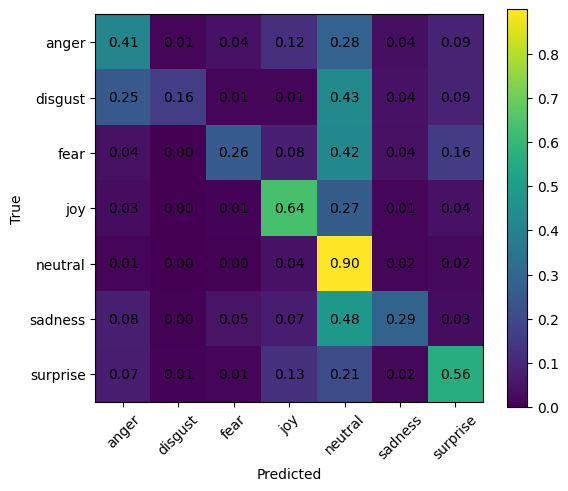

In [14]:
import matplotlib.pyplot as plt
import numpy as np

cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(6, 5))
plt.imshow(cm_normalized)
plt.colorbar()

plt.xticks(np.arange(num_classes), target_names, rotation=45)
plt.yticks(np.arange(num_classes), target_names)

for i in range(num_classes):
    for j in range(num_classes):
        value = cm_normalized[i, j]
        plt.text(j, i, f"{value:.2f}",
                 ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()